# **N-gram Language Models: Predicting the Next Word by Counting**

![rainbow](https://raw.githubusercontent.com/ancilcleetus/AI-ML-Explainers/main/assets/rainbow-divider.png)

# 📖 TABLE OF CONTENTS

- [Intro](#Intro)
- [Setup](#Setup)
- [Why Does This Matter?](#Why-Does-This-Matter?)
- [Building Intuition](#Building-Intuition)
  - [Code Walkthrough: Building Intuition Counts](#Code-Walkthrough:-Building-Intuition-Counts)
  - [What to Look For: Visualize Frequencies](#What-to-Look-For:-Visualize-Frequencies)
- [The Mathematics](#The-Mathematics)
  - [Code Walkthrough: Verify Math](#Code-Walkthrough:-Verify-Math)
- [Let's Build It — Component by Component](#Let's-Build-It-—-Component-by-Component)
  - [Code Walkthrough: N-gram Model Class](#Code-Walkthrough:-N-gram-Model-Class)
  - [Code Walkthrough: Examine Predictions](#Code-Walkthrough:-Examine-Predictions)
  - [What to Look For: Visualize Transition Matrix](#What-to-Look-For:-Visualize-Transition-Matrix)
- [References](#References)

![rainbow](https://raw.githubusercontent.com/ancilcleetus/AI-ML-Explainers/main/assets/rainbow-divider.png)

# Intro

In this notebook, we are going to build a foundational language model using N-grams, completely from scratch. By the end, we will have a working model that can generate text and understand the core ideas behind how language models predict words.

![rainbow](https://raw.githubusercontent.com/ancilcleetus/AI-ML-Explainers/main/assets/rainbow-divider.png)

# Setup

In [1]:
# 🔧 Setup: Run this cell first!
# Check GPU availability and install dependencies

import torch
import sys

# Check GPU
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f"✅ GPU available: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    device = torch.device('cpu')
    print("⚠️ No GPU detected. Some cells may run slowly.")
    print("   Go to Runtime → Change runtime type → GPU")

print(f"\n📦 Python {sys.version.split()[0]}")
print(f"🔥 PyTorch {torch.__version__}")

# Set random seeds for reproducibility
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"🎲 Random seed set to {SEED}")

%matplotlib inline

✅ GPU available: Tesla T4
   Memory: 15.6 GB

📦 Python 3.12.13
🔥 PyTorch 2.11.0+cu128
🎲 Random seed set to 42


![rainbow](https://raw.githubusercontent.com/ancilcleetus/AI-ML-Explainers/main/assets/rainbow-divider.png)

# Why Does This Matter?

Every time your phone suggests the next word, every time a chatbot completes your sentence, every time a search engine guesses what you are about to type -- a **language model** is at work. And it all started with the simplest idea imaginable: **counting.**

Before neural networks, before transformers, before GPT -- the dominant approach to language modeling was the **N-gram model.** The idea is disarmingly simple: look at the last few words, and predict what comes next based on how often you have seen that pattern before.

In this notebook, you will build an N-gram language model **completely from scratch.** No deep learning libraries, no pre-trained weights -- just Python, counting, and probability. By the end, you will have a working model that can generate (surprisingly coherent) text, and you will understand exactly why this approach eventually hit a wall that only neural networks could overcome.

**What you will build:**
- A bigram (2-gram) and trigram (3-gram) language model
- Probability estimation from raw counts
- Text generation using sampling
- Perplexity evaluation to measure model quality
- Visualizations of the sparsity problem that killed N-grams

Let us begin.

![rainbow](https://raw.githubusercontent.com/ancilcleetus/AI-ML-Explainers/main/assets/rainbow-divider.png)

# Building Intuition

Think about how you predict the next word yourself. If I say "I went to the grocery ___", you instantly think "store." Why? Because in your lifetime of reading and listening, you have encountered "grocery store" thousands of times -- far more often than "grocery elephant" or "grocery democracy."

You are doing something remarkably similar to counting: your brain has observed word patterns so frequently that the prediction feels automatic.

An N-gram model does exactly this, but explicitly. It counts every pair (or triple, or quadruple) of consecutive words in a large corpus and uses those counts to estimate probabilities.

Let us start with the simplest case: what is the probability that a given word appears at all?

## Code Walkthrough: Building Intuition Counts

In [2]:
# The foundation: word frequencies in a corpus
corpus_text = """
the cat sat on the mat
the cat ate the fish
the dog sat on the mat
the bird flew over the house
the cat sat on the rug
"""

# Tokenize
words = corpus_text.lower().split()
total_words = len(words)

# Count each word
from collections import Counter
word_counts = Counter(words)

print("Word frequencies:")
print("-" * 50)
for word, count in word_counts.most_common():
    prob = count / total_words
    print(f"'{word}': count={count}, P('{word}') = {count} / {total_words} = {prob:.3f}")

print("-" * 50)
print(f"Total words: {total_words}")
print(f"Vocabulary size: {len(word_counts)}")

Word frequencies:
--------------------------------------------------
'the': count=10, P('the') = 10 / 29 = 0.345
'cat': count=3, P('cat') = 3 / 29 = 0.103
'sat': count=3, P('sat') = 3 / 29 = 0.103
'on': count=3, P('on') = 3 / 29 = 0.103
'mat': count=2, P('mat') = 2 / 29 = 0.069
'ate': count=1, P('ate') = 1 / 29 = 0.034
'fish': count=1, P('fish') = 1 / 29 = 0.034
'dog': count=1, P('dog') = 1 / 29 = 0.034
'bird': count=1, P('bird') = 1 / 29 = 0.034
'flew': count=1, P('flew') = 1 / 29 = 0.034
'over': count=1, P('over') = 1 / 29 = 0.034
'house': count=1, P('house') = 1 / 29 = 0.034
'rug': count=1, P('rug') = 1 / 29 = 0.034
--------------------------------------------------
Total words: 29
Vocabulary size: 13


## What to Look For: Visualize Frequencies

Now let us visualize these word frequencies. This is our first look at the **distributional structure** of language.

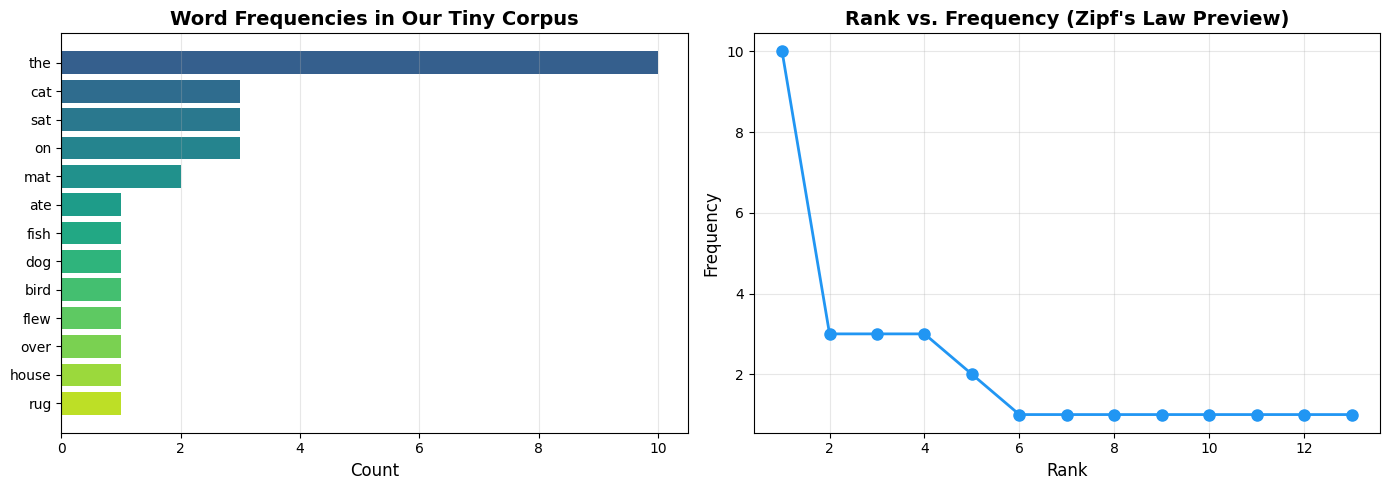

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Sort by frequency
words_sorted = word_counts.most_common()
labels = [word for word, count in words_sorted]
counts = [count for word, count in words_sorted]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of word frequencies
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(labels)))
axes[0].barh(labels[::-1], counts[::-1], color=colors[::-1])
axes[0].set_xlabel('Count', fontsize=12)
axes[0].set_title('Word Frequencies in Our Tiny Corpus', fontsize=14, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Zipf's Law Preview: Rank vs Frequency
ranks = np.arange(1, len(counts)+1)
axes[1].plot(ranks, sorted(counts, reverse=True), 'o-', color='#2196F3', markersize=8, linewidth=2)
axes[1].set_xlabel('Rank', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title("Rank vs. Frequency (Zipf's Law Preview)", fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Notice something: "the" appears far more often than any other word. This is a universal property of natural language called **Zipf's Law** -- a handful of words account for most of the text, while most words are rare. This will matter a lot when we hit the sparsity problem later.

![rainbow](https://raw.githubusercontent.com/ancilcleetus/AI-ML-Explainers/main/assets/rainbow-divider.png)

# The Mathematics

A **language model** assigns a probability to a sequence of words $w_1, w_2, \ldots, w_n$. Using the **chain rule of probability**, we decompose:

$$P(w_1, w_2, \ldots, w_n) = \prod_{i=1}^{n} P(w_i \mid w_1, \ldots, w_{i-1}) = P(w_1) \cdot P(w_2|w_1) \cdot P(w_3|w_1, w_2) \cdot ... \cdot P(w_n|w_1, w_2, ..., w_{n-1})$$

The problem: estimating $P(w_i \mid w_1, \ldots, w_{i-1})$ requires seeing the exact sequence $w_1, \ldots, w_{i-1}$ many times. For long sequences, this is practically impossible.

That's where the **Markov assumption** comes in. It simplifies things by saying we only need to look at the last few words to predict the next word. In other words, the Markov assumption fixes this by truncating the history:

- **Bigram** (n=2): $P(w_i \mid w_1, \ldots, w_{i-1}) \approx P(w_i \mid w_{i-1})$
- **Trigram** (n=3): $P(w_i \mid w_1, \ldots, w_{i-1}) \approx P(w_i \mid w_{i-2}, w_{i-1})$

We estimate these conditional probabilities by simply counting how often word pairs or triples appear in our data:

$$P(w_i \mid w_{i-1}) = \frac{\text{Count}(w_{i-1}, w_i)}{\text{Count}(w_{i-1})}$$

Let us verify this computationally. If our corpus has "cat sat" appearing 2 times and "cat" appearing 3 times, then $P(\text{sat} \mid \text{cat}) = 2/3$.

## Code Walkthrough: Verify Math

In [4]:
# Let's compute this by hand and verify
# Chain rule: P("the cat sat") = P("the") * P("cat"|"the") * P("sat"|"cat")

corpus = [
    "the cat sat on the mat",
    "the cat ate the fish",
    "the dog sat on the mat",
    "the bird flew over the house",
    "the cat sat on the rug",
]

from collections import defaultdict

# Count unigrams and bigrams
unigram_counts = defaultdict(int)
bigram_counts = defaultdict(int)

for sentence in corpus:
    words = sentence.lower().split()
    for i in range(len(words)):
        unigram_counts[words[i]] += 1
        if i < len(words)-1:
            bigram_counts[(words[i], words[i+1])] += 1

# Bigram probability
def bigram_prob(w1, w2):
    """
    P(w2|w1) = Count(w1, w2) / Count(w1)
    """
    if unigram_counts[w1] == 0:
        return 0.0
    return bigram_counts[(w1, w2)] / unigram_counts[w1]

# Compute P("the cat sat")
p_the = unigram_counts["the"] / sum(unigram_counts.values())
p_cat_given_the = bigram_prob("the", "cat")
p_sat_given_cat = bigram_prob("cat", "sat")

print("Computing P('the cat sat') using Chain Rule of Probability & Markov Assumption (Bigram):")
print(f"  P('the')         = {unigram_counts["the"]} / {sum(unigram_counts.values())} = {p_the:.4f}")
print(f"  P('cat'|'the')   = {bigram_counts[('the', 'cat')]} / {unigram_counts['the']} = {p_cat_given_the:.4f}")
print(f"  P('sat'|'cat')   = {bigram_counts[('cat', 'sat')]} / {unigram_counts['cat']} = {p_sat_given_cat:.4f}")
print(f"\n  P('the cat sat') = {p_the:.4f} × {p_cat_given_the:.4f} × {p_sat_given_cat:.4f} = {p_the * p_cat_given_the * p_sat_given_cat:.6f}")

Computing P('the cat sat') using Chain Rule of Probability & Markov Assumption (Bigram):
  P('the')         = 10 / 29 = 0.3448
  P('cat'|'the')   = 3 / 10 = 0.3000
  P('sat'|'cat')   = 2 / 3 = 0.6667

  P('the cat sat') = 0.3448 × 0.3000 × 0.6667 = 0.068966


![rainbow](https://raw.githubusercontent.com/ancilcleetus/AI-ML-Explainers/main/assets/rainbow-divider.png)

# Let's Build It — Component by Component

Now let us build a proper N-gram language model class that can handle any value of n.

## Code Walkthrough: N-gram Model Class

In [5]:
import numpy as np
from collections import defaultdict, Counter

class NgramLanguageModel:
    """
    An N-gram language model built from scratch.

    This model estimates P(next_word | previous n-1 words)
    by counting occurrences in the training corpus.
    """

    def __init__(self, n=2, smoothing=0.0):
        """
        Args:
            n: The N in N-gram (2 = bigram, 3 = trigram, etc.)
            smoothing: Laplace smoothing parameter (0 = no smoothing)
        """
        self.n = n
        self.smoothing = smoothing
        self.ngram_counts = defaultdict(int)  # Count of full n-grams
        self.context_counts = defaultdict(int)  # Count of (n-1)-gram contexts
        self.vocabulary = set()  # Set of unique words in the corpus
        self.total_tokens = 0

    def _get_ngrams(self, tokens):
        """Extract all n-grams from a list of tokens."""
        # Add start/end tokens for proper sentence boundaries
        padded = ["<s>"] * (self.n - 1) + tokens + ["</s>"]
        ngrams = []
        for i in range(len(padded) - self.n + 1):
            ngram = tuple(padded[i:i + self.n])
            ngrams.append(ngram)
        return ngrams

    def train(self, corpus):
        """
        Train the model by counting n-grams in the corpus.

        Args:
            corpus: List of sentences (strings)
        """
        for sentence in corpus:
            tokens = sentence.lower().split()
            self.vocabulary.update(tokens)
            self.total_tokens += len(tokens)

            ngrams = self._get_ngrams(tokens)
            for ngram in ngrams:
                context = ngram[:-1]  # First n-1 words
                self.ngram_counts[ngram] += 1
                self.context_counts[context] += 1

        self.vocabulary.add("<s>")
        self.vocabulary.add("</s>")

        print(f"Trained {self.n}-gram model:")
        print(f"  Vocabulary size: {len(self.vocabulary)}")
        print(f"  Total tokens: {self.total_tokens}")
        print(f"  Unique {self.n}-grams: {len(self.ngram_counts)}")
        print(f"  Unique contexts: {len(self.context_counts)}")

    def probability(self, word, context):
        """
        Compute P(word | context) using counts + optional smoothing.

        Args:
            word: The word to predict
            context: Tuple of previous (n-1) words
        """
        ngram = context + (word,)

        numerator = self.ngram_counts[ngram] + self.smoothing
        denominator = self.context_counts[context] + self.smoothing * len(self.vocabulary)

        if denominator == 0:
            return 1 / len(self.vocabulary)  # Uniform fallback

        return numerator / denominator

    def get_distribution(self, context):
        """Get the full probability distribution over vocabulary given a context."""
        dist = {}
        for word in self.vocabulary:
            dist[word] = self.probability(word, context)
        return dist

In [6]:
# Train a bigram model
corpus = [
    "the cat sat on the mat",
    "the cat ate the fish",
    "the dog sat on the mat",
    "the bird flew over the house",
    "the cat sat on the rug",
]

bigram_model = NgramLanguageModel(n=2)
bigram_model.train(corpus)

Trained 2-gram model:
  Vocabulary size: 15
  Total tokens: 29
  Unique 2-grams: 21
  Unique contexts: 14


## Code Walkthrough: Examine Predictions

Let us examine what the model learned:

In [7]:
# What does the model predict after "the"?
context = ("the",)
dist = bigram_model.get_distribution(context)

# Sort by probability
sorted_dist = sorted(dist.items(), key=lambda x: x[1], reverse=True)

print(f"P(word | 'the') -- top predictions:")
print("-" * 40)
for word, prob in sorted_dist[:10]:
    bar = "█" * int(prob * 50)
    print(f"  {word:12s}  {prob:.3f}  {bar}")

P(word | 'the') -- top predictions:
----------------------------------------
  cat           0.300  ███████████████
  mat           0.200  ██████████
  fish          0.100  █████
  house         0.100  █████
  dog           0.100  █████
  rug           0.100  █████
  bird          0.100  █████
  ate           0.000  
  <s>           0.000  
  sat           0.000  


## What to Look For: Visualize Transition Matrix

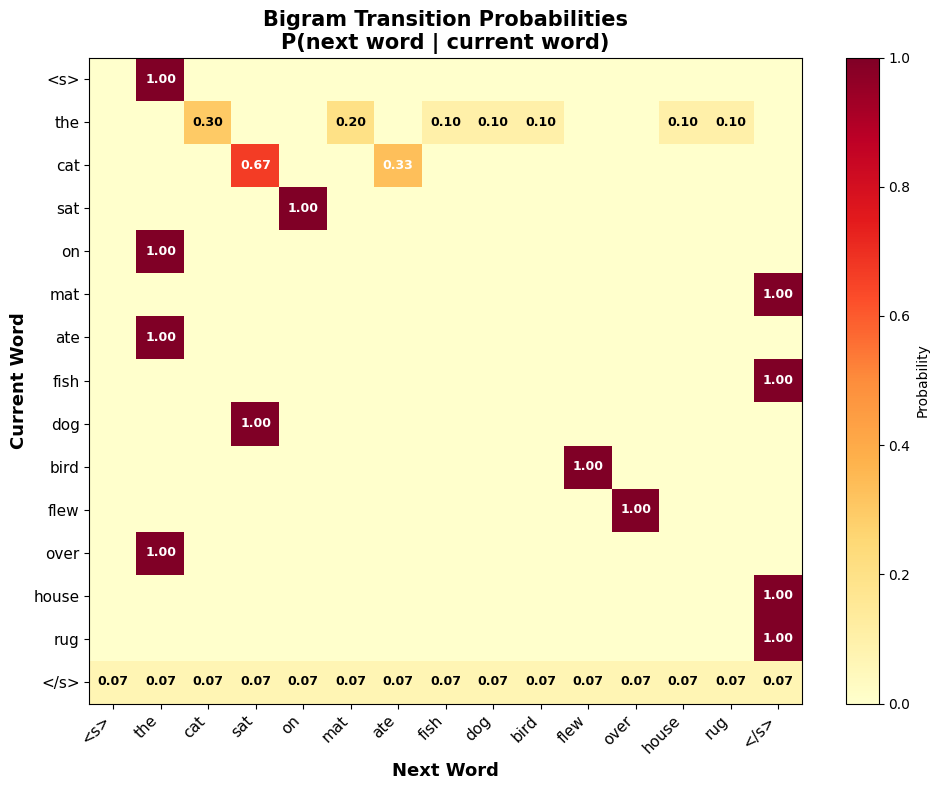

In [8]:
# Visualize the bigram transition matrix
# This is the heart of the N-gram model -- a lookup table of probabilities

# Get the most common words for visualization
common_words = [w for w, _ in Counter(
    [w for s in corpus for w in s.lower().split()]
).most_common()]
common_words = ["<s>"] + common_words + ["</s>"]

# Build transition matrix
matrix = np.zeros((len(common_words), len(common_words)))
for i, w1 in enumerate(common_words):
    for j, w2 in enumerate(common_words):
        matrix[i, j] = bigram_model.probability(w2, (w1,))

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(matrix, cmap='YlOrRd', aspect='auto')

ax.set_xticks(range(len(common_words)))
ax.set_yticks(range(len(common_words)))
ax.set_xticklabels(common_words, rotation=45, ha='right', fontsize=11)
ax.set_yticklabels(common_words, fontsize=11)

# Annotate cells with probabilities
for i in range(len(common_words)):
    for j in range(len(common_words)):
        if matrix[i, j] > 0.01:
            color = 'white' if matrix[i, j] > 0.3 else 'black'
            ax.text(j, i, f'{matrix[i, j]:.2f}', ha='center', va='center',
                    fontsize=9, color=color, fontweight='bold')

ax.set_xlabel('Next Word', fontsize=13, fontweight='bold')
ax.set_ylabel('Current Word', fontsize=13, fontweight='bold')
ax.set_title('Bigram Transition Probabilities\nP(next word | current word)',
             fontsize=15, fontweight='bold')
plt.colorbar(im, label='Probability')
plt.tight_layout()
plt.show()

![rainbow](https://raw.githubusercontent.com/ancilcleetus/AI-ML-Explainers/main/assets/rainbow-divider.png)

# References

- **[Vizuara AI](https://vizuara.ai/)**
- **Key Papers:**
  - **Shannon, C. (1948). "A Mathematical Theory of Communication"**

![rainbow](https://raw.githubusercontent.com/ancilcleetus/AI-ML-Explainers/main/assets/rainbow-divider.png)

In [ ]:
from IPython.display import Image, display, Markdown
display(Image(filename="data/images/Notebook_Template-01.png", width=500))
display(Markdown("*Notebook Template*"))

![rainbow](https://raw.githubusercontent.com/ancilcleetus/AI-ML-Explainers/main/assets/rainbow-divider.png)